# Linear Regression — Simple & Multiple
### Dataset: Diabetes Dataset (scikit-learn built-in)

**Dataset link / source:**
- Official scikit-learn documentation: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset
- Original source (Efron et al., 2004, "Least Angle Regression"): https://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf
- Raw data mirror: https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html

This dataset contains **442 diabetes patients**. Each patient has **10 baseline features**
(age, sex, BMI, average blood pressure, and 6 blood serum measurements — all mean-centered
and scaled), and the **target** is a quantitative measure of disease progression one year
after baseline.

It ships directly with scikit-learn (`sklearn.datasets.load_diabetes`), so no manual
download is required — it will load instantly in the cell below.


In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset

In [2]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame  # includes all 10 features + target column

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
df.describe()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


## 3. Quick Exploratory Data Analysis

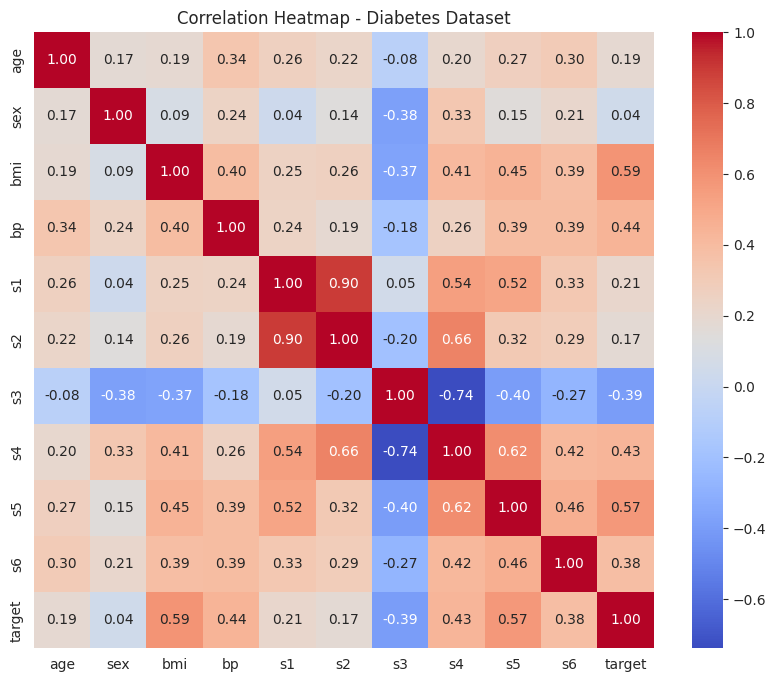

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Diabetes Dataset")
plt.show()


In [6]:
# Feature most correlated with the target -> bmi
df.corr()['target'].sort_values(ascending=False)


target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

## 4. Simple Linear Regression
We'll predict disease progression (`target`) using a **single feature**: `bmi`
(body mass index), since it has the strongest correlation with the target.


In [7]:
X_simple = df[['bmi']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

y_pred_simple = simple_model.predict(X_test)

print("Intercept:", simple_model.intercept_)
print("Coefficient (bmi):", simple_model.coef_[0])


Intercept: 152.00335421448167
Coefficient (bmi): 998.5776891375598


In [8]:
mse_s = mean_squared_error(y_test, y_pred_simple)
mae_s = mean_absolute_error(y_test, y_pred_simple)
r2_s = r2_score(y_test, y_pred_simple)

print(f"Mean Squared Error : {mse_s:.2f}")
print(f"Mean Absolute Error: {mae_s:.2f}")
print(f"R^2 Score          : {r2_s:.4f}")


Mean Squared Error : 4061.83
Mean Absolute Error: 52.26
R^2 Score          : 0.2334


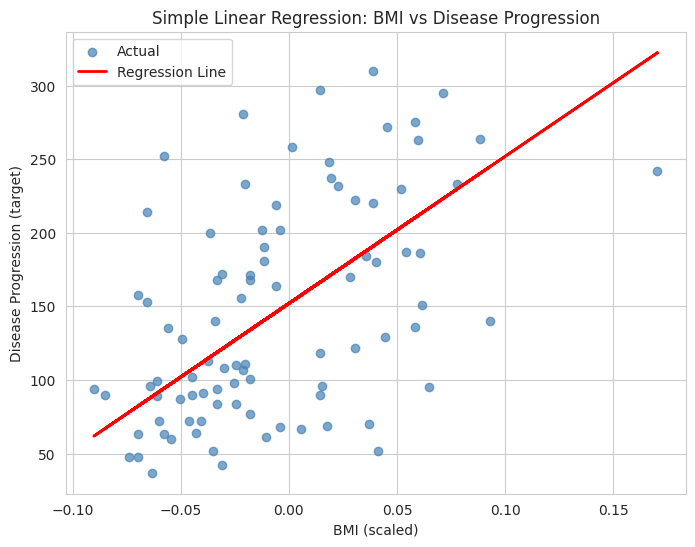

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color="steelblue", label="Actual", alpha=0.7)
plt.plot(X_test, y_pred_simple, color="red", linewidth=2, label="Regression Line")
plt.xlabel("BMI (scaled)")
plt.ylabel("Disease Progression (target)")
plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.legend()
plt.show()


## 5. Multiple Linear Regression
Now we'll use **all 10 features** (age, sex, bmi, bp, s1-s6) to predict the target.


In [10]:
X_multi = df.drop(columns=['target'])
y = df['target']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

y_pred_multi = multi_model.predict(X_test_m)

coeff_df = pd.DataFrame(
    multi_model.coef_, X_multi.columns, columns=['Coefficient']
).sort_values(by='Coefficient', ascending=False)

print("Intercept:", multi_model.intercept_)
coeff_df


Intercept: 151.34560453985995


,Coefficient
s5,736.198859
bmi,542.428759
s2,518.062277
bp,347.703844
s4,275.317902
s3,163.419983
s6,48.670657
age,37.904021
sex,-241.964362
s1,-931.488846


In [11]:
mse_m = mean_squared_error(y_test_m, y_pred_multi)
mae_m = mean_absolute_error(y_test_m, y_pred_multi)
r2_m = r2_score(y_test_m, y_pred_multi)

print(f"Mean Squared Error : {mse_m:.2f}")
print(f"Mean Absolute Error: {mae_m:.2f}")
print(f"R^2 Score          : {r2_m:.4f}")


Mean Squared Error : 2900.19
Mean Absolute Error: 42.79
R^2 Score          : 0.4526


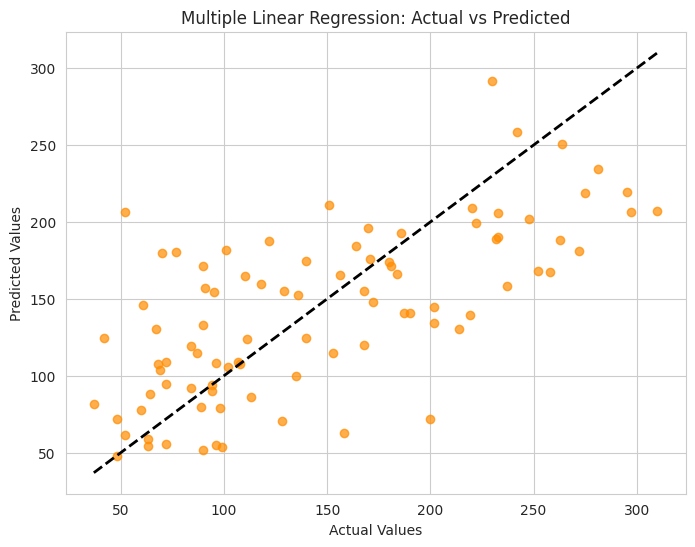

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_m, y_pred_multi, color="darkorange", alpha=0.7)
plt.plot(
    [y_test_m.min(), y_test_m.max()],
    [y_test_m.min(), y_test_m.max()],
    color="black", linestyle="--", linewidth=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()


## 6. Model Comparison

| Model | Features Used | R² Score | MSE |
|---|---|---|---|
| Simple Linear Regression | 1 (bmi) | see output above | see output above |
| Multiple Linear Regression | 10 (all) | see output above | see output above |

As expected, the multiple linear regression model (using all 10 features) achieves a
higher R² score than the simple linear regression model (using only `bmi`), since it
has access to more information to explain variation in disease progression.


In [13]:
print("Simple LR  (bmi only) - R^2:", round(r2_s, 4))
print("Multiple LR (all features) - R^2:", round(r2_m, 4))


Simple LR  (bmi only) - R^2: 0.2334
Multiple LR (all features) - R^2: 0.4526


## 7. References / Dataset Link
- scikit-learn documentation: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset
- `sklearn.datasets.load_diabetes` API reference: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
- Original paper (Efron, Hastie, Johnstone, Tibshirani, 2004): https://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf
